# AI for Molecules — Hands-on Tutorial

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Corteswain/AI4molecules-tutorial/blob/main/notebooks/AI4molecules_tutorial.ipynb)

In this 75-minute tutorial you'll build a molecular property predictor from scratch. First you'll
run a standard data-cleaning pipeline, then make four modeling decisions in sequence and check how
these choices hold up under proper cross-validation:

0. **Data cleaning** — put the raw SMILES through a standard curation
   pipeline. 
1. **Dataset splitting** — how do we split data into train and validation sets so our
   target, not any model or features.
2. **Model choice** — a classical ML model (Random Forest) on hand-crafted features, or
   a graph neural network (Chemprop) that learns its own representation? 
3. **Representation** — how do we turn a molecule (a SMILES string) into numbers a model can use?
4. **Train** — put it all together and run a quick hyperparameter search against `val`.
5. **Evaluation** — reuse every choice you made above (split method, model, representation,
   hyperparameter grid) and run a proper 3×3 nested cross-validation, to see how much your
   Step 4 result depended on luck versus how it will really hold up on data it never saw.

At each of the four modeling-decision steps (1 through 4), a few options are already implemented
as functions in `utils/`. You choose which one to plug in, run it, and then we compare notes
as a group before moving to the next step.

**Task:** predict aqueous solubility (logS) from molecular structure, using the [ESOL dataset](https://pubs.acs.org/doi/10.1021/ci034243x).


## Setup

Run the cell below once. On Colab it installs the needed packages and pulls in the `utils/` code and dataset from the tutorial repo (takes ~1-2 minutes).

In [1]:
import sys
import os
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !pip install -q rdkit scikit-learn scipy chemprop pandas matplotlib
    if not os.path.exists("AI4molecules-tutorial"):
        !git clone --quiet https://github.com/Corteswain/AI4molecules-tutorial.git
    %cd AI4molecules-tutorial
else:
    # This notebook always lives at <repo_root>/notebooks/AI4molecules_tutorial.ipynb, so
    # the repo root is exactly one directory up from here. VS Code's Jupyter extension
    # exposes the notebook's own file path as __vsc_ipynb_file__ — we use that (not the
    # kernel's working directory, which VS Code does not set to the notebook's folder).
    os.chdir(Path(__vsc_ipynb_file__).resolve().parent.parent)

sys.path.insert(0, ".")
print("Setup done. Running in Colab:", IN_COLAB, "| working directory:", os.getcwd())

Setup done. Running in Colab: False | working directory: /Users/ricbec/projects/AI4molecules-tutorial


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import spearmanr
from sklearn.metrics import r2_score

from utils.representations import REPRESENTATIONS
from utils.splitting import SPLITTERS, random_split, scaffold_split, kmeans_split, butina_split
from utils.models import MODEL_RUNNERS, run_chemprop, predict_chemprop
from utils.evaluation import NestedCVJob
from utils.cleaning import remove_invalid_smiles, canonicalize_smiles, remove_salts, remove_stereochemistry, remove_duplicates
from utils.viz import low_dimensional_representation, nearest_neighbor_similarity, cluster_sample_grid, TRAIN_COLOR, VAL_COLOR

TARGET = "measured_log_solubility_mol_per_L"
df = pd.read_csv("data/data.csv")
print(f"{len(df)} molecules")
df.head()

1015 molecules


,compound_id,smiles,measured_log_solubility_mol_per_L
0,Fenfuram,Cc1occc1C(=O)Nc2ccccc2,-3.30
1,citral,CC(C)=CCCC(C)=CC(=O),-2.06
2,Picene,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87
3,Thiophene,c1ccsc1,-1.33
4,benzothiazole,c2ccc1scnc1c2,-1.50


## Step 0 — Data cleaning

Before splitting, choosing a model, or featurizing anything, we put the raw SMILES through a
standard cheminformatics curation pipeline.

- **`remove_invalid_smiles`** — drops rows RDKit can't parse at all. Has to run first: every
  other step assumes a valid molecule.
- **`canonicalize_smiles`** — rewrites every SMILES into RDKit's canonical form, so two ways of
  writing the same molecule aren't treated as different molecules downstream.
- **`remove_salts`** — strips counterions/salt fragments (e.g. "CCN.Cl" → "CCN"), keeping only
  the parent molecule.
- **`remove_stereochemistry`** — removes chiral tags.
- **`remove_duplicates`** — drops duplicate molecules, keeping the first occurrence.

Run the cell below to apply them one at a time, in order — each one prints how many molecules it
actually changed.

In [3]:
print(f"Starting with {len(df)} molecules")

df = remove_duplicates(df, target_col=TARGET)
df = remove_invalid_smiles(df)
df = canonicalize_smiles(df)
df = remove_salts(df)
df = remove_stereochemistry(df)
df = remove_duplicates(df, target_col=TARGET)

print(f"Finished with {len(df)} molecules")

Starting with 1015 molecules
remove_duplicates: removed 5 duplicate row(s) (5 duplicate molecule(s)) — 2 group(s) agreed on 'measured_log_solubility_mol_per_L', 3 group(s) disagreed
remove_invalid_smiles: removed 0 unparseable row(s), 1010 remain
canonicalize_smiles: rewrote 499 SMILES into canonical form
remove_salts: stripped a salt/counterion from 0 molecule(s)
remove_stereochemistry: 0 molecule(s) had exactly 1 tetrahedral stereocenter removed, 0 molecule(s) had 2+ tetrahedral stereocenters removed
remove_duplicates: removed 4 duplicate row(s) (4 duplicate molecule(s)) — 3 group(s) agreed on 'measured_log_solubility_mol_per_L', 1 group(s) disagreed
Finished with 1006 molecules


**Discuss:**
- Which of these steps are "easy" in the sense that they do not require real decision-making? Which of them are a modelling choice already?
- `remove_duplicates` reported some duplicate groups that *disagree* on the target value.
  Could an earlier step make two different
  molecules look identical? What could be other explanations?

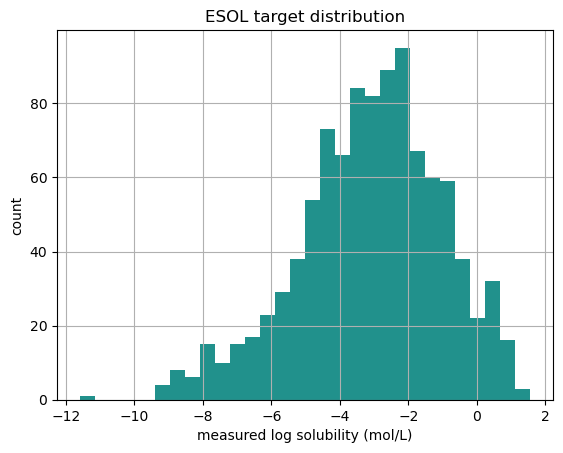

In [4]:
df[TARGET].hist(bins=30, color=plt.cm.viridis(0.5))
plt.xlabel("measured log solubility (mol/L)")
plt.ylabel("count")
plt.title("ESOL target distribution")
plt.show()

## Step 1 — Dataset splitting

We start here because splitting only touches the SMILES and the target — it doesn't depend on a
model or a representation, so there's no reason to decide those first. Every split function
returns **two** sets: `train` and `val`. We're deliberately doing everything in this tutorial
with a single train/val split, at a small scale, so the whole workflow — including the
hyperparameter search in Step 4 — stays easy to see end to end. `val` is the only held-out data
this notebook has access to; there's a genuinely fresh evaluation set too, but it's kept
completely outside this notebook, for later.

How we split molecules changes what our evaluation actually measures. Four options are
implemented in `utils/splitting.py`, each targeting ~20% val (train gets the rest):

- **`random`** — a plain i.i.d. shuffle-and-split. No relationship between molecules is considered.
- **`scaffold`** — molecules are grouped by [Bemis-Murcko scaffold](https://en.wikipedia.org/wiki/Bemis%E2%80%93Murcko_scaffold) (their shared ring/core structure); whole scaffold groups go to train or val, so near-identical molecules can't leak across the split.
- **`kmeans`** — molecules are clustered by *Euclidean* distance between fingerprint vectors (KMeans), and whole clusters are held out for val.
- **`butina`** — molecules are clustered by *Tanimoto* similarity between fingerprints ([Butina clustering](https://www.rdkit.org/docs/Cookbook.html#clustering-molecules), the standard cheminformatics notion of "similar molecule"), and whole clusters are held out for val.

`kmeans` and `butina` both aim to test extrapolation to structurally distinct
regions of chemical space, but they can disagree with each other: two molecules "close" by
Euclidean distance aren't guaranteed to be "close" by Tanimoto similarity, especially near cluster
boundaries.

Running random_split...
  done — 805 train / 201 val
Running scaffold_split...
  done — 842 train / 164 val
Running kmeans_split...
  done — 831 train / 175 val
Running butina_split...
  done — 853 train / 153 val


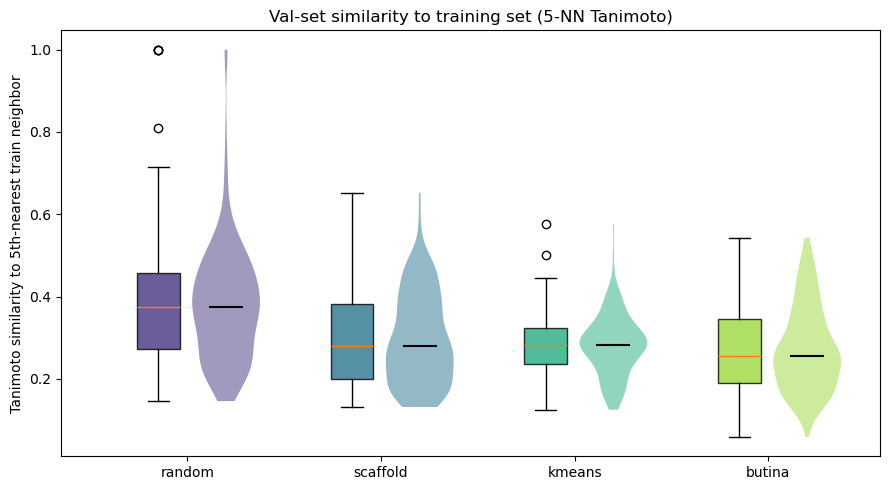

random    : median=0.375  mean=0.380
scaffold  : median=0.279  mean=0.296
kmeans    : median=0.282  mean=0.281
butina    : median=0.256  mean=0.272


In [5]:
print("Running random_split...")
random_train_idx, random_val_idx = random_split(df, val_size=0.2, seed=42)
print(f"  done — {len(random_train_idx)} train / {len(random_val_idx)} val")

print("Running scaffold_split...")
scaffold_train_idx, scaffold_val_idx = scaffold_split(df, val_size=0.2, seed=42)
print(f"  done — {len(scaffold_train_idx)} train / {len(scaffold_val_idx)} val")

print("Running kmeans_split...")
kmeans_train_idx, kmeans_val_idx = kmeans_split(df, val_size=0.2, seed=42)
print(f"  done — {len(kmeans_train_idx)} train / {len(kmeans_val_idx)} val")

print("Running butina_split...")
butina_train_idx, butina_val_idx = butina_split(df, val_size=0.2, seed=42)
print(f"  done — {len(butina_train_idx)} train / {len(butina_val_idx)} val")

splits = {
    "random": (random_train_idx, random_val_idx),
    "scaffold": (scaffold_train_idx, scaffold_val_idx),
    "kmeans": (kmeans_train_idx, kmeans_val_idx),
    "butina": (butina_train_idx, butina_val_idx),
}


nn_sim_stats = nearest_neighbor_similarity(df, splits, k=5)

**Discuss**: For each split, how Tanimoto-similar
is each val molecule to its 5th-nearest neighbor in that split's training set? What does this mean for ehe expected performance of your model on the validation set? On a test set On real-life data? 

Now pick one of the four to inspect more closely.

Using random: 805 train / 201 val


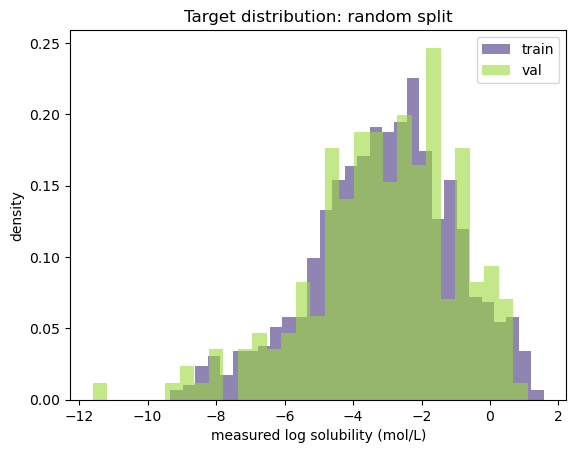

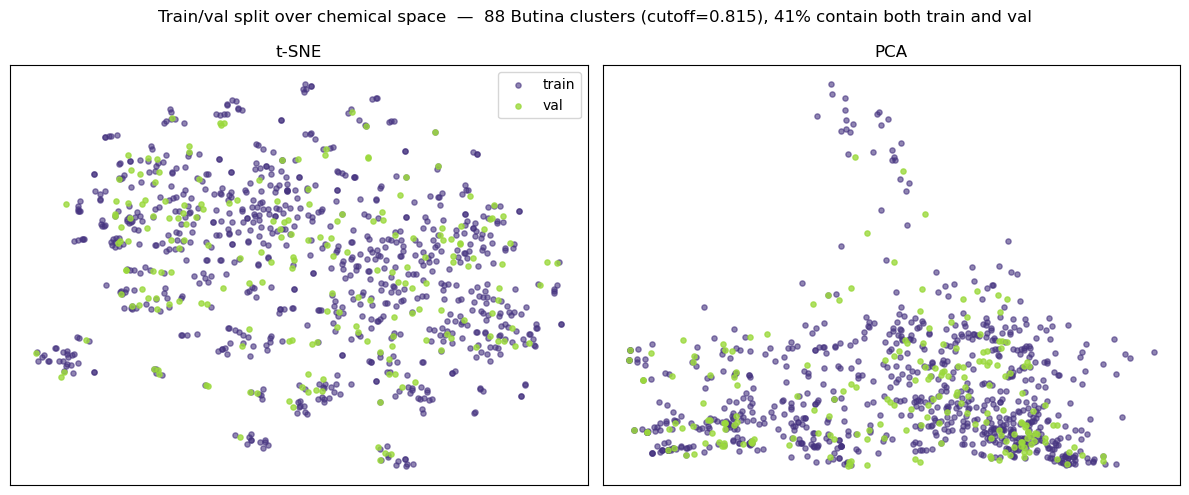

36/88 Butina clusters (41%) contain both train and val molecules.


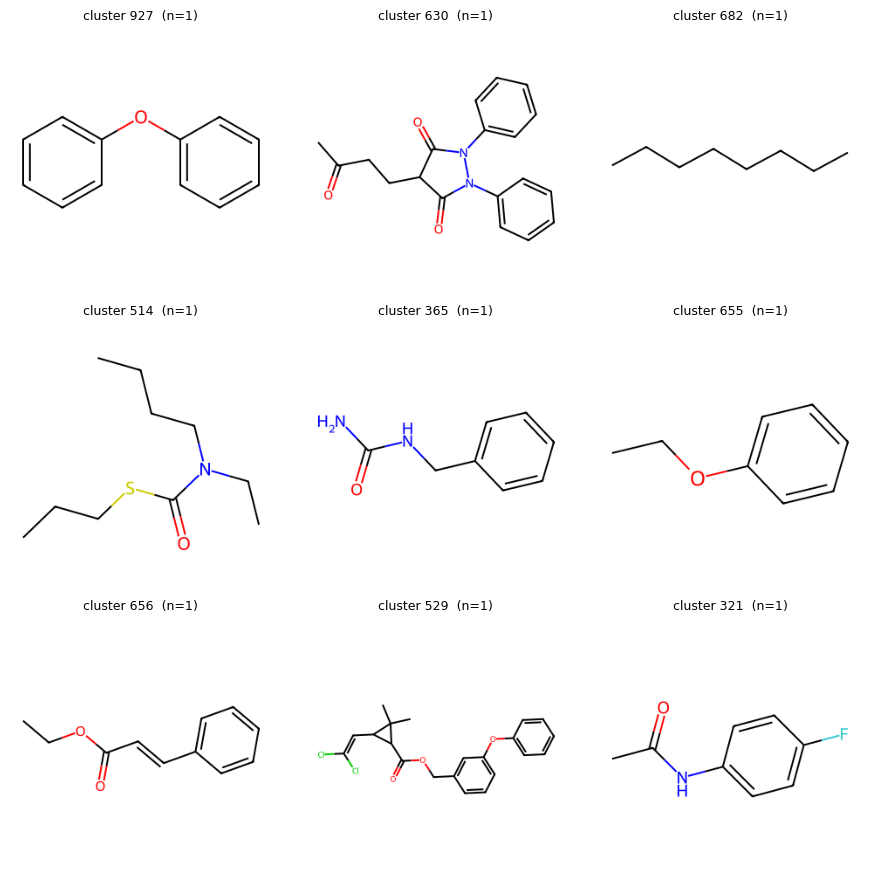

In [6]:
# ---- YOUR CHOICE ----
SPLIT_METHOD = "random"  # options: "random", "scaffold", "kmeans", "butina"
# ----------------------

train_idx, val_idx = splits[SPLIT_METHOD]
train_df = df.iloc[train_idx].reset_index(drop=True)
val_df = df.iloc[val_idx].reset_index(drop=True)
y_train = df[TARGET].values[train_idx]
y_val = df[TARGET].values[val_idx]

print(f"Using {SPLIT_METHOD}: {len(train_idx)} train / {len(val_idx)} val")

plt.hist(y_train, bins=30, alpha=0.6, label="train", density=True, color=TRAIN_COLOR)
plt.hist(y_val, bins=30, alpha=0.6, label="val", density=True, color=VAL_COLOR)
plt.xlabel("measured log solubility (mol/L)")
plt.ylabel("density")
plt.legend()
plt.title(f"Target distribution: {SPLIT_METHOD} split")
plt.show()

split_stats = low_dimensional_representation(df, train_idx, val_idx)

cluster_sample_grid(df, SPLIT_METHOD)

## Step 2 — Model choice

Now that the split is fixed, decide which model to train. This choice determines whether
hand-crafting features (Step 3) is even part of the workflow. Two options are implemented in
`utils/models.py`:

- **`random_forest`** — a classical ML model. It needs a fixed-size feature vector per molecule,
  which means *you* have to decide how to turn a molecule into numbers (Step 3).
- **`chemprop`** — a message-passing graph neural network (MPNN) that learns its own representation
  directly from the molecular graph, end to end, while training. It doesn't need a hand-crafted
  feature vector from Step 3 to get started — but it isn't feature-blind either; see Step 3 for
  what it uses by default and how to extend it.

Pick one below. 

In [7]:
# ---- YOUR CHOICE ----
MODEL = "chemprop"  # options: "random_forest", "chemprop"
# ----------------------

print(f"Selected model: {MODEL}")
if MODEL == "chemprop":
    print("Chemprop learns its own representation from the molecular graph — Step 3's functions won't apply, but see Step 3 for its default features.")

Selected model: chemprop
Chemprop learns its own representation from the molecular graph — Step 3's functions won't apply, but see Step 3 for its default features.


**Discuss:**
- Which one of these models do you expect more data?
- Which one do you expect to need more compute time?

## Step 3 — Representation

For `random_forest`, pick how to turn a molecule into numbers. There are infinitely many options, but we implemented two of them here:

- **`morgan`** — Morgan (circular) fingerprints: a 1024-bit vector encoding which local substructures are present.
- **`rdkit_descriptors`** — 217 global physicochemical descriptors: molecular weight, LogP, TPSA, H-bond donors/acceptors, rotatable bonds, ring counts...

**If you picked `chemprop` in Step 2, these two functions don't apply to it** - but that doesn't
mean representation is irrelevant to Chemprop. It already makes a representation choice by
default (a fixed set of per-atom and per-bond features it builds the molecular graph from), and,
like the options above, that default can be swapped out or extended with your own hand-crafted
features. See the [Chemprop v2 documentation](https://chemprop.readthedocs.io/en/latest/) for the
full set of options.

Chemprop v2's *default* atom featurizer one-hots atomic number over ~37 elements (H through
Kr, plus iodine), since it's built to handle arbitrary molecules. `run_chemprop` overrides this
with chemprop's built-in **`organic`** scheme instead -- a smaller, fixed vocabulary of the elements organic/drug-like molecules actually
use (H, B, C, N, O, F, Si, P, S, Cl, Br, I). ESOL only ever contains C, O, N, Cl, S, F, Br, P,
and I, so that vocabulary already covers everything here.

- **Node (atom) features — 44 values per atom** (down from 72 with the default scheme):
  atomic number (one-hot over H, B, C, N, O, F, Si, P, S, Cl, Br, I), degree, formal charge,
  chiral tag, number of attached hydrogens, hybridization (s / sp / sp² / sp³ — the `organic`
  scheme also drops the rarer sp²d / sp³d / sp³d² bits the default includes), aromaticity, and
  atomic mass.
- **Edge (bond) features — 14 values per bond** (unchanged — the featurizer mode only affects
  atoms): a "null" padding bit, bond type (single/double/triple/aromatic), whether it's
  conjugated, whether it's in a ring, and its stereochemistry (E/Z or none).

Pick one below (ignored if `MODEL == "chemprop"`).

By the end of this cell, `MODEL`, `SPLIT_METHOD`, and `REPRESENTATION` are all fixed. That's
enough to also fix Step 4's hyperparameter grid and kick off Step 5's 3×3 nested cross-validation
right away, on a background thread, instead of waiting until Step 4 is done. It's slow enough
that starting it this early gives it the longest possible head start, so it's likely already
done (or closer to done) by the time you reach Step 5.

In [8]:
# ---- YOUR CHOICE ----
REPRESENTATION = "morgan"  # options: "morgan", "rdkit_descriptors"
# ----------------------

if MODEL == "chemprop":
    print("MODEL = 'chemprop' — it builds its own representation from the graph, so this choice will be ignored in Step 4.")
    X_train = X_val = None
else:
    featurize = REPRESENTATIONS[REPRESENTATION]
    X_train = featurize(train_df["smiles"].tolist())
    X_val = featurize(val_df["smiles"].tolist())
    print(f"{REPRESENTATION}: X_train.shape = {X_train.shape}")

if MODEL == "chemprop":
    param_grid = [{"depth": 2}, {"depth": 4}]
else:  # random_forest
    param_grid = [{"n_estimators": 100}, {"n_estimators": 300}]

cv_job = NestedCVJob(df, SPLIT_METHOD, MODEL, REPRESENTATION, param_grid, TARGET, k_outer=3, k_inner=3, seed=42)
print("\nStarted Step 5's 3x3 nested cross-validation in the background.")

MODEL = 'chemprop' — it builds its own representation from the graph, so this choice will be ignored in Step 4.

Started Step 5's 3x3 nested cross-validation in the background.


**Discuss:**
- What representation did we choose earlier to create the data split? Could we have chosen a different representation? SHOULD we have chosen a different one?
- What are the benefits and drawbacks of letting a model *learn* its own representation instead of hand-designing one?
- Could you look at this feature vector and explain *why* the model made a given prediction?
- We do not have the time to manually optimise chemprop's features, but what would you like to change if given the opportunity?


## Step 4 — Train

Train `MODEL` on the `SPLIT_METHOD` split, using the `REPRESENTATION` features (if you picked `random forest`). 
Rather than training once with fixed settings, it is important to **optimise hyperparameters**: comparing two unoptimised models
is no very meaningful.
Here, we keep the optimisation to a minimum, but I tested parameters beforehand to make sure that our search grid is reasonable.

The hyperparameter grid itself was already fixed back in Step 3, right after `REPRESENTATION`
was chosen — that's also when Step 5's 3×3 nested cross-validation started running in the
background, reusing this same grid. This cell just runs that same grid once, synchronously, on
the single `train`/`val` split from Step 1.

In [9]:
if MODEL == "chemprop":
    trials = []
    for params in param_grid:
        r = run_chemprop(train_df, val_df, target_col=TARGET, epochs=15, **params)
        trials.append((params, r))
        print(f"  {params}: val RMSE = {r['rmse']:.3f}, R2 = {r['r2']:.3f}, trainable params = {r['n_params']:,}")
    label = f"{MODEL} ({SPLIT_METHOD} split, learned representation)"

else:  # random_forest
    trials = []
    for params in param_grid:
        r = MODEL_RUNNERS[MODEL](X_train, y_train, X_val, y_val, **params)
        trials.append((params, r))
        print(f"  {params}: val RMSE = {r['rmse']:.3f}, R2 = {r['r2']:.3f}, trainable params = {r['n_params']:,}")
    label = f"{MODEL} ({SPLIT_METHOD} split, {REPRESENTATION} representation)"

best_params, result = min(trials, key=lambda pr: pr[1]["rmse"])
print()
print(f"Best config: {best_params}")
print(label)
print(f"val: RMSE = {result['rmse']:.3f}   R2 = {result['r2']:.3f}")

  {'depth': 2}: val RMSE = 1.086, R2 = 0.748, trainable params = 301,501
  {'depth': 4}: val RMSE = 0.985, R2 = 0.793, trainable params = 301,501

Best config: {'depth': 4}
chemprop (random split, learned representation)
val: RMSE = 0.985   R2 = 0.793


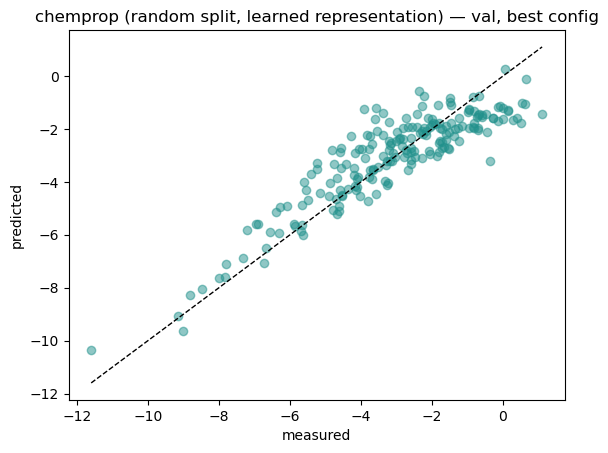

In [10]:
y_pred = result["y_pred"]
lims = [min(y_val.min(), y_pred.min()), max(y_val.max(), y_pred.max())]
plt.scatter(y_val, y_pred, alpha=0.5, color=plt.cm.viridis(0.5))
plt.plot(lims, lims, "k--", linewidth=1)
plt.xlabel("measured")
plt.ylabel("predicted")
plt.title(f"{label} — val, best config")
plt.show()

**Discuss:**
- How does your best val RMSE/R² compare to what your neighbor got with a different choice at any step?

## Step 5 — Evaluation

So far you've handcrafted a model that performs well on a *single* validation set. That tells
you almost nothing about whether it'll extrapolate to new molecules — you tuned choices in 
Step 4 specifically to make it look good on that one `val`.

To find out, Step 3 already kicked off a proper **3×3 nested cross-validation** in the
background, reusing the exact choices you've already made — `SPLIT_METHOD`, `MODEL`,
`REPRESENTATION`, and the hyperparameter grid — just applied repeatedly instead of once:

- The full dataset is partitioned into **3 outer test folds**, grouped the same way
  `SPLIT_METHOD` groups molecules and containing 15% of the total data.
- For each outer fold, the *other* 85% of the data is partitioned again into **3 inner
  train/val splits** — the same kind of split as Step 1, just repeated.
- For each inner split: repeat Step 4's hyperparameter search on inner-train/inner-val, keep
  whichever config scores best on inner-val, and evaluate *that* model on the outer test
  fold — data it never saw and never influenced, at any point.

That gives **3 independently-trained models per outer test fold**, so instead of one number per
fold we get a small distribution: 3 models, each optimized completely independently, all scored
against the exact same held-out molecules. Below, R² and Spearman rank correlation are plotted
per outer fold.

This trains 9 models end to end (3 outer × 3 inner).
We have been running these in the background since Step 3. Random Forest models should be finished at this point,
Chemprop calculations might take a few minutes.

In [11]:
cv_job.wait()

cv_results = cv_job.cv_results
ensemble = cv_job.ensemble
cv_df = pd.DataFrame(cv_results)
print(f"{len(cv_df)} models trained across {cv_df['outer_fold'].nunique()} outer test folds, {len(ensemble)} models kept in `ensemble` for Step 6.")

Waiting for the background 3x3 cross-validation to finish...
Background CV done: 9 models trained.
9 models trained across 3 outer test folds, 9 models kept in `ensemble` for Step 6.


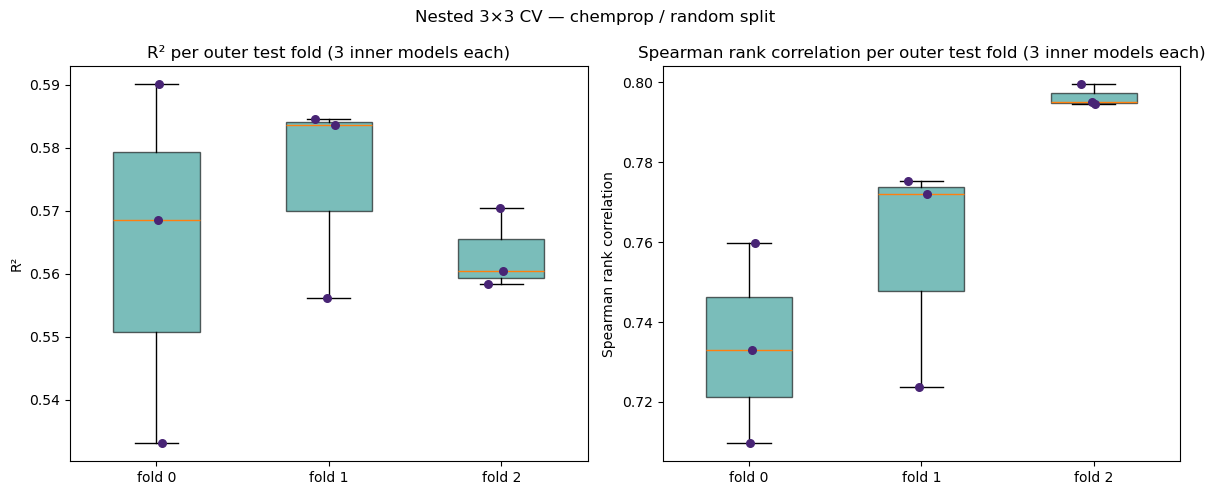

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
n_outer = cv_df["outer_fold"].nunique()
positions = np.arange(1, n_outer + 1)

for ax, metric, title in [(axes[0], "r2", "R\u00b2"), (axes[1], "spearman", "Spearman rank correlation")]:
    data = [cv_df.loc[cv_df["outer_fold"] == i, metric].values for i in range(n_outer)]
    box = ax.boxplot(data, positions=positions, widths=0.5, patch_artist=True, showfliers=False)
    for patch in box["boxes"]:
        patch.set_facecolor(plt.cm.viridis(0.5))
        patch.set_alpha(0.6)
    for i, vals in enumerate(data):
        jitter = np.random.RandomState(i).uniform(-0.08, 0.08, size=len(vals))
        ax.scatter(np.full(len(vals), positions[i]) + jitter, vals, color=plt.cm.viridis(0.1), zorder=3, s=30)
    ax.set_xticks(positions)
    ax.set_xticklabels([f"fold {i}" for i in range(n_outer)])
    ax.set_ylabel(title)
    ax.set_title(f"{title} per outer test fold (3 inner models each)")

extra = f", {REPRESENTATION}" if MODEL != "chemprop" else ""
fig.suptitle(f"Nested 3\u00d73 CV \u2014 {MODEL} / {SPLIT_METHOD} split{extra}")
plt.tight_layout()
plt.show()

**Discuss:**

- Look *across* test folds — do some outer folds look consistently harder than others?
  What would make one fold of molecules intrinsically harder to predict than another?
- Now look at the spread *within* a single test fold (3 dots, one box). How much does performance
  vary just based on the test/validation split?
- Compare these results to the single number you got in Step 4. Was that number near the
  middle of this distribution, or was it an (un)lucky outlier?

## Step 6 — Application

Time to use what you built. `data/real.csv` is 113 molecules held out of this entire tutorial
from the very start — nothing in Steps 0-5 has ever seen them, trained on them, or been tuned
to look good on them. Pretend they just arrived from the lab.

We apply the **full ensemble of 9 models from Step 5** — not just one model. The same way the
Step 5 box plots gave you a spread instead of a single number, the ensemble gives each molecule
in `real.csv` 9 predictions instead of one: a mean (the ensemble's best guess) and a spread
(how much the 9 models disagree with each other, which is itself informative).

`real.csv` is new data, so it needs the same cleaning pipeline as Step 0 before
anything can be done with it — a model can't be handed raw SMILES it's never had to deal with
consistently. Run the cell below to load and clean it.

In [13]:
real_df = pd.read_csv("data/real.csv")
print(f"Loaded {len(real_df)} molecules from data/real.csv")

real_df = remove_invalid_smiles(real_df)
real_df = canonicalize_smiles(real_df)
real_df = remove_salts(real_df)
real_df = remove_stereochemistry(real_df)
real_df = remove_duplicates(real_df, target_col=TARGET)

print(f"{len(real_df)} molecules after cleaning")

Loaded 113 molecules from data/real.csv
remove_invalid_smiles: removed 0 unparseable row(s), 113 remain
canonicalize_smiles: rewrote 74 SMILES into canonical form
remove_salts: stripped a salt/counterion from 0 molecule(s)
remove_stereochemistry: 0 molecule(s) had exactly 1 tetrahedral stereocenter removed, 0 molecule(s) had 2+ tetrahedral stereocenters removed
remove_duplicates: removed 2 duplicate row(s) (2 duplicate molecule(s)) — 0 group(s) agreed on 'measured_log_solubility_mol_per_L', 2 group(s) disagreed
111 molecules after cleaning


In [14]:
if MODEL == "chemprop":
    all_preds = np.stack([predict_chemprop(entry["work_dir"], real_df, smiles_col="smiles") for entry in ensemble])
else:
    X_real = REPRESENTATIONS[REPRESENTATION](real_df["smiles"].tolist())
    all_preds = np.stack([entry["model"].predict(X_real) for entry in ensemble])

print(f"all_preds.shape = {all_preds.shape}  ({all_preds.shape[0]} models x {all_preds.shape[1]} molecules)")

y_real = real_df[TARGET].values
pred_mean = all_preds.mean(axis=0)
pred_std = all_preds.std(axis=0)

ensemble_r2 = r2_score(y_real, pred_mean)
ensemble_spearman = spearmanr(y_real, pred_mean).correlation
print(f"Ensemble mean vs. real.csv: R2 = {ensemble_r2:.3f}   spearman = {ensemble_spearman:.3f}")

all_preds.shape = (9, 111)  (9 models x 111 molecules)
Ensemble mean vs. real.csv: R2 = 0.345   spearman = 0.661


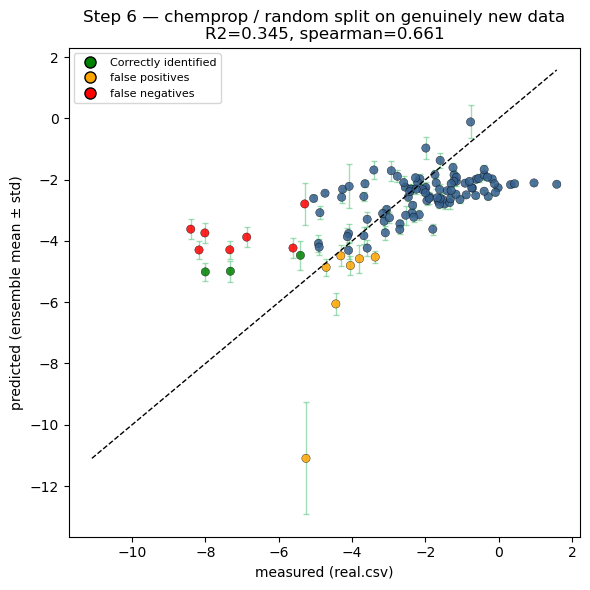

In [15]:
n_bottom = 10
real_lowest_idx = set(np.argsort(y_real)[:n_bottom])
pred_lowest_idx = set(np.argsort(pred_mean)[:n_bottom])

point_colors = []
for i in range(len(y_real)):
    if i in real_lowest_idx and i in pred_lowest_idx:
        point_colors.append("green")
    elif i in pred_lowest_idx:
        point_colors.append("orange")
    elif i in real_lowest_idx:
        point_colors.append("red")
    else:
        point_colors.append(plt.cm.viridis(0.3))

fig, ax = plt.subplots(figsize=(6, 6))
ax.errorbar(
    y_real, pred_mean, yerr=pred_std, fmt="none", alpha=0.5,
    ecolor=plt.cm.viridis(0.7), elinewidth=1, capsize=2, zorder=1,
)
ax.scatter(y_real, pred_mean, c=point_colors, alpha=0.85, zorder=2, edgecolor="black", linewidth=0.3)
lims = [min(y_real.min(), pred_mean.min()), max(y_real.max(), pred_mean.max())]
ax.plot(lims, lims, "k--", linewidth=1)
ax.set_xlabel("measured (real.csv)")
ax.set_ylabel("predicted (ensemble mean ± std)")
ax.set_title(
    f"Step 6 — {MODEL} / {SPLIT_METHOD} split on genuinely new data\n"
    f"R2={ensemble_r2:.3f}, spearman={ensemble_spearman:.3f}"
)
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="green", markeredgecolor="black", markersize=8,
           label="Correctly identified"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="orange", markeredgecolor="black", markersize=8,
           label="false positives"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="red", markeredgecolor="black", markersize=8,
           label="false negatives"),
]
ax.legend(handles=legend_elements, loc="best", fontsize=8)
plt.tight_layout()
plt.show()